In [ ]:
!pip install openpyxl

/tmp/ipykernel_1105/964408611.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap("tab20", 20)  # 20 colores base


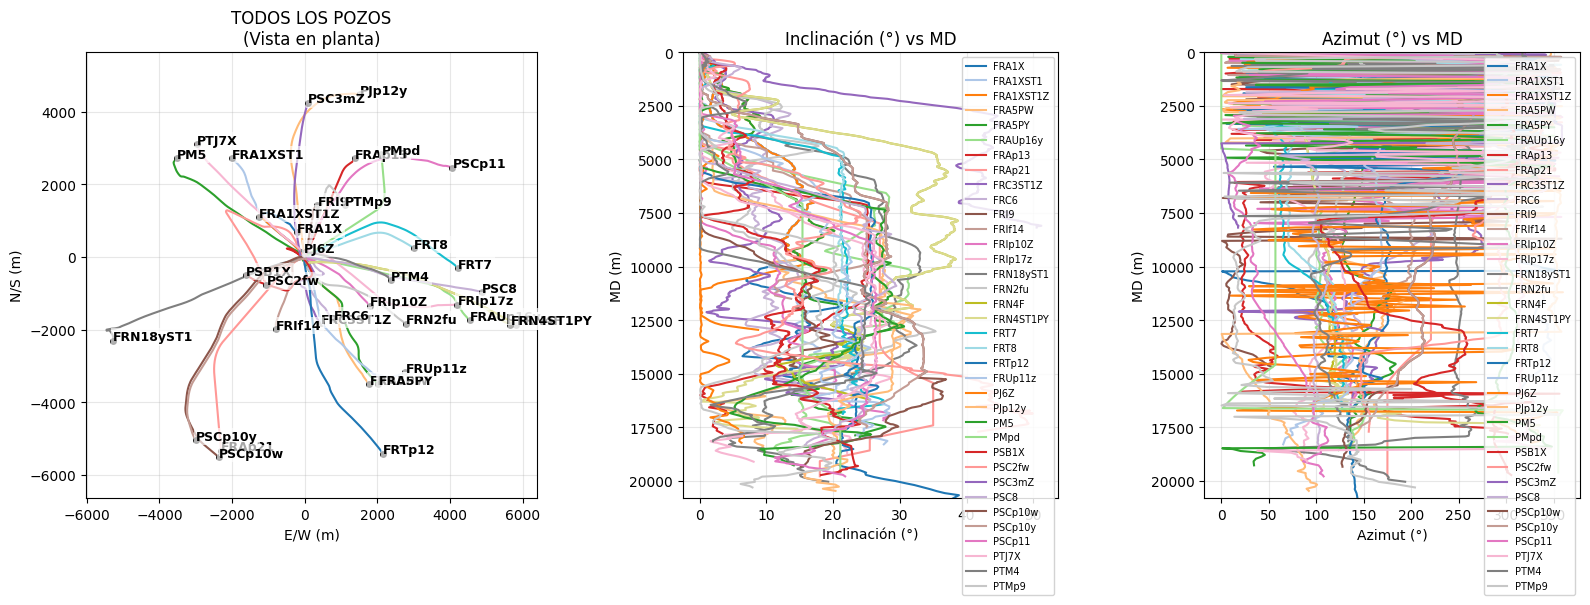

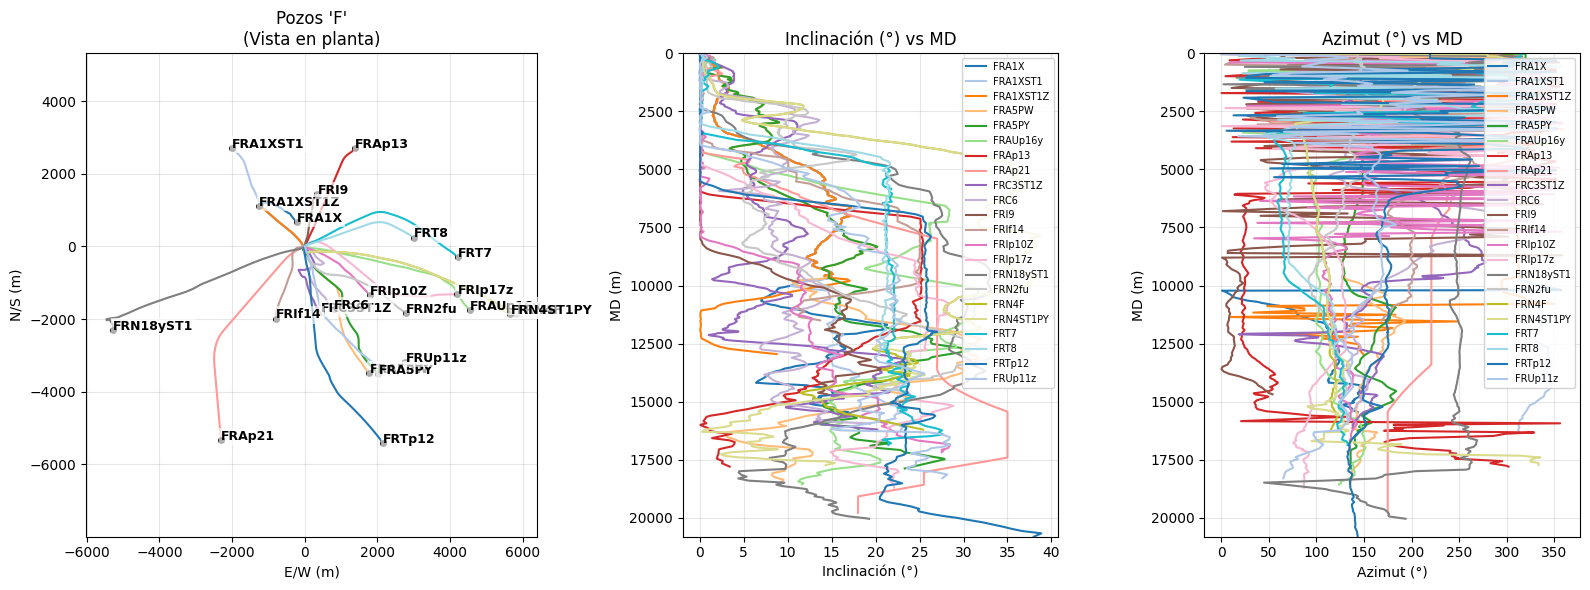

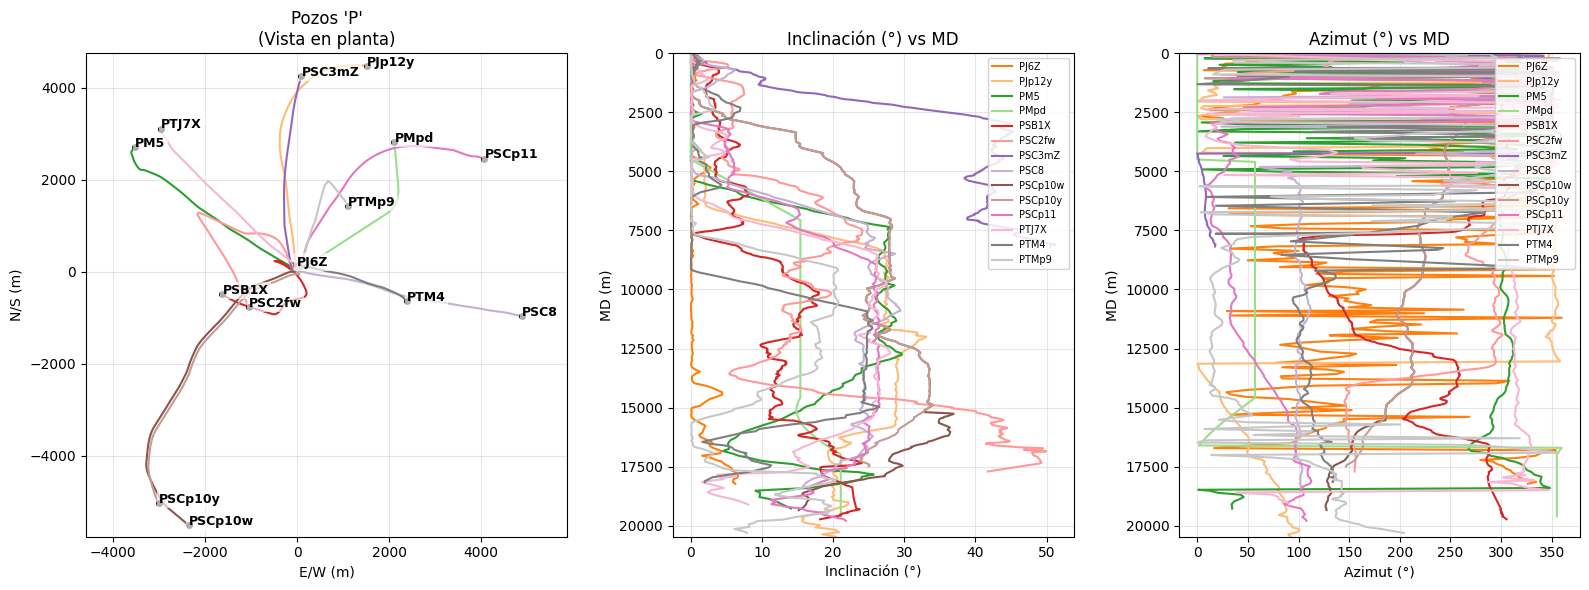

In [ ]:
# ============================================================
#  PANELES: PLANTA + INCLINACIÓN + AZIMUT (Y invertido)
#  - Planta sin leyenda, etiqueta en el endpoint
#  - Inclinación/Azimut con leyenda pequeña en esquina superior derecha
#  - Colores consistentes por pozo
#  Colab, archivo en /content
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# -----------------------------
# 1) Archivo y lectura
# -----------------------------
FILE_PATH = "/content/Trayectorias_Piedemonte_all.xlsx"  # <-- cambia el nombre si hace falta
SHEET_NAME = 0  # primera hoja

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"No encuentro el archivo: {FILE_PATH}. Verifica que esté en /content.")

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine="openpyxl")
df.columns = [c.strip() for c in df.columns]

# Requisitos mínimos
req = ["Pozo", "MD", "Incl", "Azi", "N/S", "E/W"]
missing = [c for c in req if c not in df.columns]
if missing:
    raise KeyError(f"Faltan columnas: {missing} ; se requieren {req}")

# Tipos y orden
for c in ["MD", "Incl", "Azi", "N/S", "E/W"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = (
    df.dropna(subset=["Pozo", "MD"])
      .sort_values(["Pozo", "MD"])
      .reset_index(drop=True)
)
df["Pozo"] = df["Pozo"].astype(str)

# -----------------------------
# 2) Paleta consistente por pozo
# -----------------------------
pozos = df["Pozo"].unique().tolist()
base_cmap = cm.get_cmap("tab20", 20)  # 20 colores base
colors = [base_cmap(i % 20) for i in range(len(pozos))]
COLOR_BY_WELL = dict(zip(pozos, colors))

# -----------------------------
# 3) Función de panel (3 subplots)
# -----------------------------
def panel_planta_incl_azi(
    data,
    title,
    dx=2.0, dy=2.0,          # offset de la etiqueta en planta (metros)
    mark_end=True,           # marcar punto final en planta
    legend_fontsize=7,       # leyenda pequeña
    legend_alpha=0.85        # transparencia del recuadro de leyenda
):
    """
    Panel con:
      - [0] Vista en planta (sin leyenda), etiquetas en el endpoint.
      - [1] Inclinación (°) vs MD (Y invertido) con leyenda arriba-derecha.
      - [2] Azimut (°) vs MD (Y invertido) con leyenda arriba-derecha.
    Colores consistentes por pozo en las tres vistas.
    """
    d = data.dropna(subset=["E/W", "N/S", "MD"])
    if d.empty:
        print(f"[Aviso] Sin datos válidos para: {title}")
        return

    # Rango de MD para fijar e invertir el eje Y
    md_min = d["MD"].min()
    md_max = d["MD"].max()

    fig, axes = plt.subplots(
        ncols=3, nrows=1, figsize=(16, 6), gridspec_kw={"width_ratios": [1.2, 1, 1]}
    )
    ax_planta, ax_incl, ax_azi = axes

    # ---------- (0) Vista en planta (sin leyenda) ----------
    for well, g in d.groupby("Pozo"):
        g = g.sort_values("MD")
        ax_planta.plot(g["E/W"], g["N/S"], color=COLOR_BY_WELL.get(well, "C0"))

        # endpoint válido y etiqueta con leve offset
        ew = g["E/W"].to_numpy()
        ns = g["N/S"].to_numpy()
        mask = ~(np.isnan(ew) | np.isnan(ns))
        if mask.any():
            ew_end = ew[mask][-1]
            ns_end = ns[mask][-1]
            ax_planta.text(
                ew_end + dx, ns_end + dy, str(well),
                fontsize=9, weight="bold", color="black",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1.5)
            )
            if mark_end:
                ax_planta.plot(ew_end, ns_end, "o", ms=4, color="k", alpha=0.85)

    ax_planta.set_title(f"{title}\n(Vista en planta)")
    ax_planta.set_xlabel("E/W (m)")
    ax_planta.set_ylabel("N/S (m)")
    ax_planta.axis("equal")
    ax_planta.grid(True, alpha=0.3)
    # Sin leyenda en planta

    # ---------- (1) Inclinación vs MD (Y invertido, con leyenda) ----------
    d_incl = d.dropna(subset=["Incl"])
    for well, g in d_incl.groupby("Pozo"):
        ax_incl.plot(g["Incl"], g["MD"], label=str(well), color=COLOR_BY_WELL.get(well, "C0"))
    ax_incl.set_title("Inclinación (°) vs MD")
    ax_incl.set_xlabel("Inclinación (°)")
    ax_incl.set_ylabel("MD (m)")
    ax_incl.set_ylim(md_max, md_min)  # profundidad hacia abajo
    ax_incl.grid(True, alpha=0.3)
    ax_incl.legend(loc="upper right", fontsize=legend_fontsize, framealpha=legend_alpha, ncol=1)

    # ---------- (2) Azimut vs MD (Y invertido, con leyenda) ----------
    d_azi = d.dropna(subset=["Azi"])
    for well, g in d_azi.groupby("Pozo"):
        ax_azi.plot(g["Azi"], g["MD"], label=str(well), color=COLOR_BY_WELL.get(well, "C0"))
    ax_azi.set_title("Azimut (°) vs MD")
    ax_azi.set_xlabel("Azimut (°)")
    ax_azi.set_ylabel("MD (m)")
    ax_azi.set_ylim(md_max, md_min)  # profundidad hacia abajo
    ax_azi.grid(True, alpha=0.3)
    ax_azi.legend(loc="upper right", fontsize=legend_fontsize, framealpha=legend_alpha, ncol=1)

    fig.tight_layout()
    plt.show()

# -----------------------------
# 4) Paneles solicitados
# -----------------------------
# Todos los pozos
panel_planta_incl_azi(
    df, "TODOS LOS POZOS",
    dx=2.0, dy=2.0, mark_end=True,
    legend_fontsize=7, legend_alpha=0.85
)

# Pozos que inician con 'F'
df_F = df[df["Pozo"].str.startswith("F", na=False)]
if not df_F.empty:
    panel_planta_incl_azi(
        df_F, "Pozos 'F'",
        dx=2.0, dy=2.0, mark_end=True,
        legend_fontsize=7, legend_alpha=0.85
    )
else:
    print("No hay pozos que inicien con 'F'.")

# Pozos que inician con 'P'
df_P = df[df["Pozo"].str.startswith("P", na=False)]
if not df_P.empty:
    panel_planta_incl_azi(
        df_P, "Pozos 'P'",
        dx=2.0, dy=2.0, mark_end=True,
        legend_fontsize=7, legend_alpha=0.85
    )
else:
    print("No hay pozos que inicien con 'P'.")

### Gráficas para pozos específicos


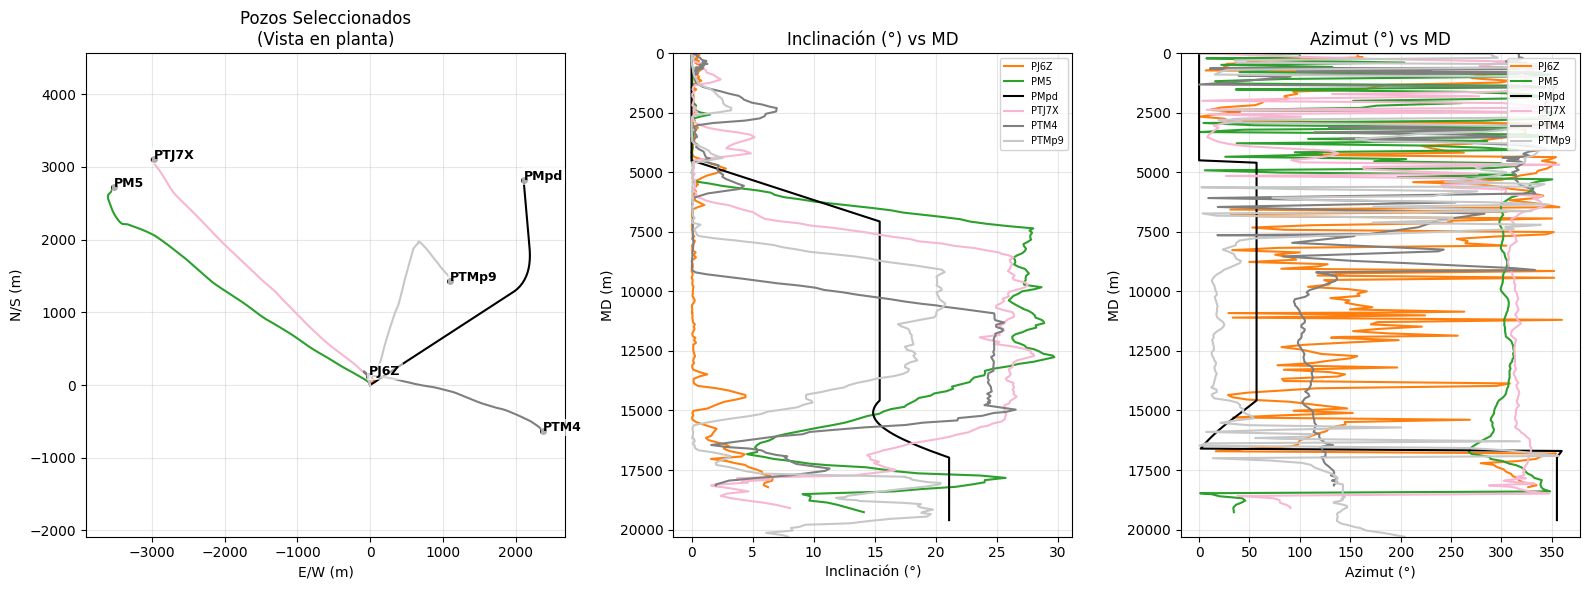

In [ ]:
#'FRA1X', 'FRA1XST1Z', 'FRA1XST1', 'FRA5PY', 'FRA5PW','FRAp13', 'FRT7', 'FRT8', 'FRTp12', 'FRAp21', FRN18yST1

pozos_seleccionados = [
    'PM5', 'PTMp9', 'PTM4', 'PMpd',
    'PJ6Z', 'PTJ7X'
]

# Establecer el color para 'FRAp21' a negro
COLOR_BY_WELL['PMpd'] = (0.0, 0.0, 0.0, 1.0) # Negro

df_seleccion = df[df['Pozo'].isin(pozos_seleccionados)].copy()

if not df_seleccion.empty:
    panel_planta_incl_azi(
        df_seleccion,
        "Pozos Seleccionados",
        dx=2.0, dy=2.0, mark_end=True,
        legend_fontsize=7, legend_alpha=0.85
    )
else:
    print("No se encontraron datos para los pozos seleccionados.")